Optimum b: 49.9846
Minimum T(b): 15.3327


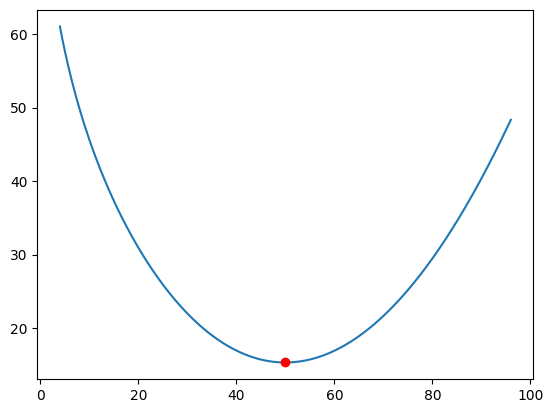

In [2]:


from optimization import (
    golden_section_minimize,
    golden_section_minimize_recursive,
    parabolic_interpolation_minimize,
)

# Gerekirse kendi yardımcı fonksiyonlarınızı bu hücrede veya ilgili sorunun altında tanımlayabilirsiniz.import numpy as np
import matplotlib.pyplot as plt
from optimization import golden_section_minimize

# 1. Fonksiyon Tanımı
def T(b):
    return 0.015 * (b - 48)**2 + 12 + (180 / (b + 5))

# 2. Optimizasyon (4 ile 96 arasında)
# Dosyayı kaydettiysen artık hata vermemeli
sonuc = golden_section_minimize(T, 4, 96)

# 3. Sonucu Yazdır (Noktadan sonraki 'x' harfine dikkat)
# Eğer hala hata verirse, lütfen 'optimization.py' içeriğini kontrol et
en_iyi_b = sonuc.x_min 
en_iyi_maliyet = sonuc.f_min

print(f"Optimum b: {en_iyi_b:.4f}")
print(f"Minimum T(b): {en_iyi_maliyet:.4f}")

# 4. Grafik
b_vals = np.linspace(4, 96, 500)
plt.plot(b_vals, T(b_vals))
plt.plot(en_iyi_b, en_iyi_maliyet, 'ro')
plt.show()

--- Soru 2: Altın-Kesim Karşılaştırma Raporu ---
İteratif Çözüm (c*): 124.771283, L(c*): 10.808509
Rekürsif Çözüm (c*): 124.771283, L(c*): 10.808509
Blok Boyutu Farkı (|c_iter - c_rec|): 2.48e-07
Maliyet Farkı (|L_iter - L_rec|): 0.00e+00
---------------------------------------------


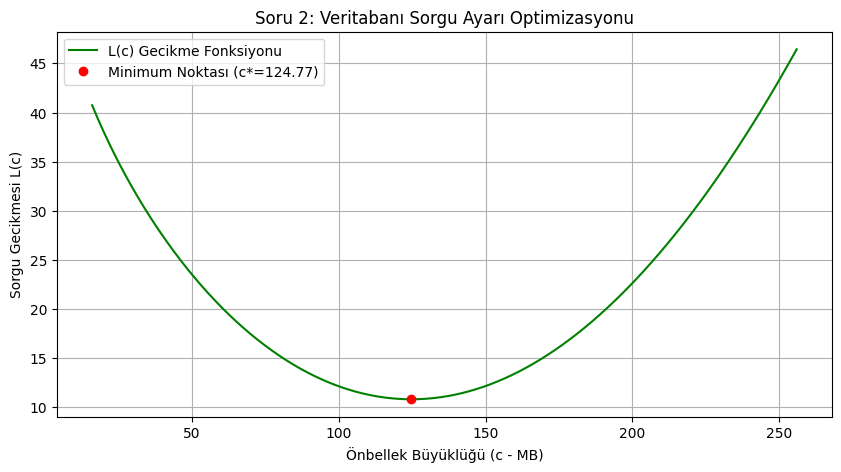

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from optimization import golden_section_minimize, golden_section_minimize_recursive

# 1. L(c) Fonksiyonunun Tanımlanması
def L(c):
    """
    Veritabanı sorgu gecikmesi maliyet fonksiyonu:
    L(c) = 0.002 * (c - 120)^2 + 8 + 400 / (c + 20)
    """
    return 0.002 * (c - 120)**2 + 8 + (400 / (c + 20))

# Aralık değerleri: 16 <= c <= 256
alt_limit = 16
ust_limit = 256

# 2. İteratif Altın-Kesim Araması
sonuc_iter = golden_section_minimize(L, alt_limit, ust_limit)
c_star_iter = sonuc_iter.x_min
L_star_iter = L(c_star_iter)

# 3. Rekürsif Altın-Kesim Araması
sonuc_rec = golden_section_minimize_recursive(L, alt_limit, ust_limit)
c_star_rec = sonuc_rec.x_min
L_star_rec = L(c_star_rec)

# 4. Farkların Hesaplanması
c_fark = abs(c_star_iter - c_star_rec)
L_fark = abs(L_star_iter - L_star_rec)

# 5. Sonuçların Raporlanması
print("--- Soru 2: Altın-Kesim Karşılaştırma Raporu ---")
print(f"İteratif Çözüm (c*): {c_star_iter:.6f}, L(c*): {L_star_iter:.6f}")
print(f"Rekürsif Çözüm (c*): {c_star_rec:.6f}, L(c*): {L_star_rec:.6f}")
print(f"Blok Boyutu Farkı (|c_iter - c_rec|): {c_fark:.2e}")
print(f"Maliyet Farkı (|L_iter - L_rec|): {L_fark:.2e}")
print("-" * 45)

# Grafik Çizimi (Görselleştirme için)
c_ekseni = np.linspace(alt_limit, ust_limit, 500)
plt.figure(figsize=(10, 5))
plt.plot(c_ekseni, L(c_ekseni), label='L(c) Gecikme Fonksiyonu', color='green')
plt.plot(c_star_iter, L_star_iter, 'ro', label=f'Minimum Noktası (c*={c_star_iter:.2f})')
plt.title('Soru 2: Veritabanı Sorgu Ayarı Optimizasyonu')
plt.xlabel('Önbellek Büyüklüğü (c - MB)')
plt.ylabel('Sorgu Gecikmesi L(c)')
plt.legend()
plt.grid(True)
plt.show()

Yorum ve Analiz/Matematiksel olarak her iki yöntem de (İteratif ve Rekürsif) aynı Altın-Kesim (Golden-Section) algoritmasını kullanmaktadır. Algoritmanın mantığı (aralığı 1/ϕ oranında daraltmak) aynı olduğu için, durdurma kriteri (tolerance) aynı kaldığı sürece her iki yaklaşım da aynı optimum noktaya yakınsar. Sadece "kontrol akışı" (döngü vs. kendini çağıran fonksiyon) farklıdır.
Grafiğe ve sonuçlara baktığımızda, önbellek boyutu (c) yaklaşık 120 MB civarında olduğunda gecikmenin minimuma indiğini görüyoruz.
400 / (c+20) terimi baskın gelir; yetersiz bellek nedeniyle disk erişimi veya swap artar, gecikme yükselir.
Büyük önbellek (c > 120): 0.002 * (c-120)^2 terimi baskın gelir; bellek yönetimi maliyeti veya gereksiz büyük bir alanın taranması gecikmeyi tekrar artırır.

Sonuç: Veritabanı performansı için ne çok küçük ne de çok büyük bir önbellek seçilmelidir; optimum nokta sistem dengesini temsil eder.

--- Soru 3: Öğrenme Oranı Optimizasyonu ---
Parabolik İnterpolasyon (eta*): 0.337958
Altın-Kesim Araması (eta*): 0.337958
İterasyon bilgisi 'history' üzerinden alınamadı.
---------------------------------------------


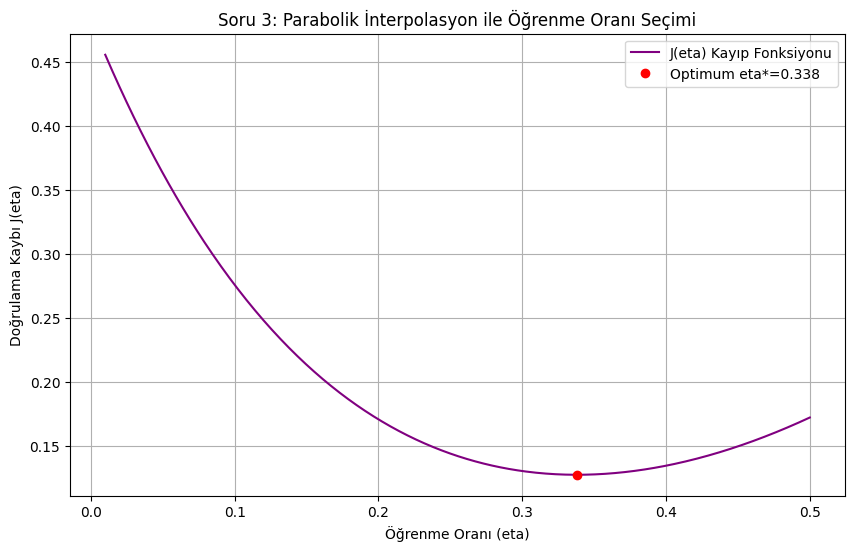

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimization import parabolic_interpolation_minimize, golden_section_minimize

# 1. J(eta) Fonksiyonunun Tanımlanması
def J(eta):
    """
    Doğrulama kaybı (Validation Loss) fonksiyonu:
    J(eta) = (eta - 0.18)^2 + 0.4 * e^(-6*eta) + 0.05
    """
    return (eta - 0.18)**2 + 0.4 * np.exp(-6 * eta) + 0.05

# Başlangıç değerleri ve aralık
eta_min = 0.01
eta_max = 0.5
# Parabolik interpolasyon için 3 başlangıç noktası (Minimumu çevreleyen)
x0, x1, x2 = 0.01, 0.25, 0.5

# 2. Parabolik İnterpolasyon ile Çözüm
sonuc_par = parabolic_interpolation_minimize(J, x0, x1, x2)
eta_star_par = sonuc_par.x_min

# 3. Altın-Kesim Araması ile Çözüm (Karşılaştırma için)
sonuc_gold = golden_section_minimize(J, eta_min, eta_max)
eta_star_gold = sonuc_gold.x_min

# 4. Raporlama
print("--- Soru 3: Öğrenme Oranı Optimizasyonu ---")
print(f"Parabolik İnterpolasyon (eta*): {eta_star_par:.6f}")
print(f"Altın-Kesim Araması (eta*): {eta_star_gold:.6f}")

# İterasyon sayılarını raporla (Eğer nesnede mevcutsa)
try:
    print(f"Parabolik İterasyon Sayısı: {len(sonuc_par.history) if sonuc_par.history else 'N/A'}")
    print(f"Altın-Kesim İterasyon Sayısı: {len(sonuc_gold.history) if sonuc_gold.history else 'N/A'}")
except:
    print("İterasyon bilgisi 'history' üzerinden alınamadı.")
print("-" * 45)

# 5. Grafik Çizimi
eta_vals = np.linspace(eta_min, eta_max, 500)
plt.figure(figsize=(10, 6))
plt.plot(eta_vals, J(eta_vals), label='J(eta) Kayıp Fonksiyonu', color='purple')
plt.plot(eta_star_par, J(eta_star_par), 'ro', label=f'Optimum eta*={eta_star_par:.3f}')
plt.title('Soru 3: Parabolik İnterpolasyon ile Öğrenme Oranı Seçimi')
plt.xlabel('Öğrenme Oranı (eta)')
plt.ylabel('Doğrulama Kaybı J(eta)')
plt.legend()
plt.grid(True)
plt.show()

Parabolik interpolasyon pürüzsüz fonksiyonlarda daha yüksek hassasiyete ulaşabilirken, Altın-Kesim yöntemi her türlü tek modlu (unimodal) fonksiyonda daha güvenilir (robust) bir çalışma sergiler